[0.11029547 0.10714782 0.11852834 0.08642614 0.098353   0.11804863
 0.12271013 0.13902193 0.09946855]


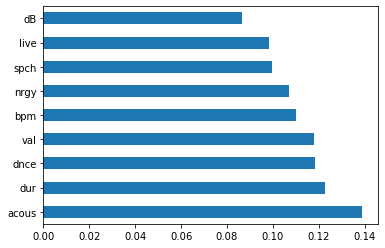

     bpm  nrgy  dnce  dB  live  val  dur  acous  spch
184  186    83    53  -5    15   16  219      1     7
497  140    71    67  -4    10   35  273     11     9
20    86    57    51  -6     9   69  171     53    26
465  124    87    71  -4    13   80  206      7     8
50   180    79    55  -3    42   36  176     10    14
..   ...   ...   ...  ..   ...  ...  ...    ...   ...
615  162    64    69  -5     8   60  172      3    16
134  160    83    67  -5    71   76  208      7     9
438  130    90    72  -3    13   61  218      1    10
18   100    60    68  -6    46   52  199     10     4
502  105    80    63  -4    11   15  197     52     5

[126 rows x 9 columns]


array(['GOT7', 'BTS', 'MAMAMOO', 'TWICE', 'GOT7', 'MOMOLAND', 'ITZY',
       'Red Velvet', 'BLACKPINK', 'MAMAMOO', 'iKON', 'TWICE', 'MOMOLAND',
       'MAMAMOO', 'BTS', 'MAMAMOO', 'MOMOLAND', 'Red Velvet', 'TWICE',
       'TWICE', 'MAMAMOO', 'iKON', 'Red Velvet', 'iKON', 'TWICE',
       'Red Velvet', 'iKON', 'Red Velvet', 'Red Velvet', 'ITZY', 'iKON',
       'TWICE', 'iKON', 'BTS', 'GOT7', 'Red Velvet', 'Red Velvet',
       'MAMAMOO', 'Red Velvet', 'Red Velvet', 'Red Velvet', 'iKON',
       'GOT7', 'Lady Gaga', 'TWICE', 'BTS', 'iKON', 'MAMAMOO',
       'Red Velvet', 'BTS', 'TWICE', 'ITZY', 'iKON', 'GOT7', 'MAMAMOO',
       'BTS', 'Red Velvet', 'BLACKPINK', 'MAMAMOO', 'iKON', 'TWICE',
       'iKON', 'ITZY', 'TWICE', 'Red Velvet', 'GOT7', 'BTS', 'Red Velvet',
       'MAMAMOO', 'Red Velvet', 'Red Velvet', 'iKON', 'Red Velvet',
       'GOT7', 'BLACKPINK', 'ITZY', 'ITZY', 'BTS', 'GOT7', 'MAMAMOO',
       'BTS', 'MAMAMOO', 'GOT7', 'Red Velvet', 'GOT7', 'B.I',
       'Red Velvet', 'GOT7', 'GO

In [49]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import joblib
from sklearn import tree
import numpy as np


# music_data = pd.read_csv('music.csv')
# x = music_data.drop(columns=['genre'])
# y = music_data['genre']
# model = DecisionTreeClassifier()
# model.fit(x,y)
# tree.export_graphviz(model, out_file='music-recommender.dot',
#                     feature_names=['age', 'gender'],
#                     class_names= sorted(y.unique()),
#                     label='all',
#                     rounded=True,
#                     filled = True)



music_data = pd.read_csv('ai music.csv')
x = music_data.drop(columns=['title', 'artist', 'top genre', 'added', 'year', 'pop', 'song id'])
y = music_data['artist']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)


from sklearn.ensemble import ExtraTreesClassifier
import matplotlib.pyplot as plt
model1 = ExtraTreesClassifier()
model1.fit(x_train,y_train)
print(model1.feature_importances_) #use inbuilt class feature_importances of tree based classifiers
#plot graph of feature importances for better visualization
feat_importances = pd.Series(model1.feature_importances_, index=x.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()






model = DecisionTreeClassifier()
model.fit(x_train,y_train)
tree.export_graphviz(model, out_file='kpop.dot',
                    feature_names=['bpm', 'nrgy', 'dnce', 'dB', 'live', 'val', 'dur', 'acous', 'spch'],
                    class_names= sorted(y.unique()),
                    label='all',
                    rounded=True,
                    filled = True)



#predictions = model.predict([[115,90,  84,-4,  27,  64,189,  9,  5,    45]])
# predictions
predictions = model.predict(x_test)
print(x_test)
predictions
# score = accuracy_score(y_test, predictions)
# score

# model = joblib.load('music-recommender.joblib')
# predictions = model.predict([[21,1]])
# predictions


In [ ]:

# music_data = pd.read_csv('music.csv')
# x = music_data.drop(columns=['genre'])
# y = music_data['genre']
# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# model = DecisionTreeClassifier()
# model.fit(x_train,y_train)
# predictions = model.predict(x_test)
# score = accuracy_score(y_test, predictions)
# score

In [166]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials #To access authorised Spotify data
import time
import numpy as np
import pandas as pd
import csv

def albumSongs(uri):
    album = uri #assign album uri to a_name
    spotify_albums[album] = {} #Creates dictionary for that specific album
    # #Create keys-values of empty lists inside nested dictionary for album
    spotify_albums[album]['album'] = [] #create empty list
    spotify_albums[album]['track_number'] = []
    spotify_albums[album]['id'] = []
    spotify_albums[album]['name'] = []
    spotify_albums[album]['uri'] = []
    tracks = sp.album_tracks(album) #pull data on album tracks
    for n in range(len(tracks['items'])): #for each song track
        spotify_albums[album]['album'].append(album_names[album_count]) #append album name tracked via album_count
        spotify_albums[album]['track_number'].append(tracks['items'][n]['track_number'])
        spotify_albums[album]['id'].append(tracks['items'][n]['id'])
        spotify_albums[album]['name'].append(tracks['items'][n]['name'])
        spotify_albums[album]['uri'].append(tracks['items'][n]['uri'])

def audio_features(album):
    #Add new key-values to store audio features
    spotify_albums[album]['acousticness'] = []
    spotify_albums[album]['danceability'] = []
    spotify_albums[album]['energy'] = []
    spotify_albums[album]['instrumentalness'] = []
    spotify_albums[album]['liveness'] = []
    spotify_albums[album]['loudness'] = []
    spotify_albums[album]['speechiness'] = []
    spotify_albums[album]['tempo'] = []
    spotify_albums[album]['valence'] = []
    spotify_albums[album]['popularity'] = []
    #create a track counter
    track_count = 0
    for track in spotify_albums[album]['uri']:
        #pull audio features per track
        features = sp.audio_features(track)
        
        #Append to relevant key-value
        spotify_albums[album]['acousticness'].append(features[0]['acousticness'])
        spotify_albums[album]['danceability'].append(features[0]['danceability'])
        spotify_albums[album]['energy'].append(features[0]['energy'])
        spotify_albums[album]['instrumentalness'].append(features[0]['instrumentalness'])
        spotify_albums[album]['liveness'].append(features[0]['liveness'])
        spotify_albums[album]['loudness'].append(features[0]['loudness'])
        spotify_albums[album]['speechiness'].append(features[0]['speechiness'])
        spotify_albums[album]['tempo'].append(features[0]['tempo'])
        spotify_albums[album]['valence'].append(features[0]['valence'])
        #popularity is stored elsewhere
        pop = sp.track(track)
        spotify_albums[album]['popularity'].append(pop['popularity'])
        track_count+=1
 

client_id = "d2f71d7536264534aad2f7c9f6100ef8"
client_secret = "647740f812c04376afd7a6d960db6f0a"
client_credentials_manager = SpotifyClientCredentials(client_id=client_id, client_secret=client_secret)
sp = spotipy.Spotify(client_credentials_manager=client_credentials_manager) #spotify object to access API
artistsList = []
first_pick = input("First Artist to Analyse:") 
artistsList.append(first_pick)
second_pick = input("Second Artist to Analyse:") 
artistsList.append(second_pick)
print(artistsList)
counter = 0
for j in artistsList:
    counter +=1
    artist = j #chosen artist
    result = sp.search(artist) 
    result['tracks']['items'][0]['artists']

    artist_uri = result['tracks']['items'][0]['artists'][0]['uri']#Pull all of the artist's albums
    sp_albums = sp.artist_albums(artist_uri, album_type='album')#Store artist's albums' names' and uris in separate lists
    album_names = []
    album_uris = []
    for i in range(len(sp_albums['items'])):
        album_names.append(sp_albums['items'][i]['name'])
        album_uris.append(sp_albums['items'][i]['uri'])
    album_names
    album_uris


    spotify_albums = {}
    album_count = 0
    for i in album_uris: #each album
        albumSongs(i)
#         print("Album " + str(album_names[album_count]) + " songs has been added to spotify_albums dictionary")
        album_count+=1 #Updates album count once all tracks have been added




    sleep_min = 2
    sleep_max = 5
    start_time = time.time()
    request_count = 0
    for i in spotify_albums:
        audio_features(i)
        request_count+=1
        if request_count % 5 == 0:
#             print(str(request_count) + " playlists completed")
            time.sleep(np.random.uniform(sleep_min, sleep_max))
#             print('Loop #: {}'.format(request_count))
#             print('Elapsed Time: {} seconds'.format(time.time() - start_time))

    dic_df = {}
    dic_df['album'] = []
    dic_df['track_number'] = []
    dic_df['id'] = []
    dic_df['name'] = []
    dic_df['uri'] = []
    dic_df['acousticness'] = []
    dic_df['danceability'] = []
    dic_df['energy'] = []
    dic_df['instrumentalness'] = []
    dic_df['liveness'] = []
    dic_df['loudness'] = []
    dic_df['speechiness'] = []
    dic_df['tempo'] = []
    dic_df['valence'] = []
    dic_df['popularity'] = []
    for album in spotify_albums: 
        for feature in spotify_albums[album]:
            dic_df[feature].extend(spotify_albums[album][feature])
        if counter == 1:
            dic_df['Artist']= artistsList[0]
        else:
            dic_df['Artist']= artistsList[1]
#     print(dic_df['Artist'])

    len(dic_df['album'])


    df = pd.DataFrame.from_dict(dic_df)
#     print(df)
#     print(len(df))
    final_df = df.sort_values('popularity', ascending=False).drop_duplicates('name').sort_index()
#     print(len(final_df))


    if counter == 1:
        final_df.to_csv("Spotipy-stats.csv") # To init the file
    else:
        final_df.to_csv("Spotipy-stats.csv", mode='a', header=False) # To append to the new file

s = 0

gapminder = pd.read_csv('Spotipy-stats.csv')
# print(gapminder.head())
first_acousticness = 100 * gapminder.groupby('Artist').acousticness.mean()
first_danceability = 100 * gapminder.groupby('Artist').danceability.mean()
first_energy = 100 * gapminder.groupby('Artist').energy.mean()
first_instrumentalness = 100 * gapminder.groupby('Artist').instrumentalness.mean()
first_liveness = 100 * gapminder.groupby('Artist').liveness.mean()
first_speechiness = 100 * gapminder.groupby('Artist').speechiness.mean()
first_tempo = 100 * gapminder.groupby('Artist').tempo.mean()
first_valence = 100 * gapminder.groupby('Artist').valence.mean()
first_popularity = 100 * gapminder.groupby('Artist').popularity.mean()

# print(first_acousticness[0])
val_1 = first_acousticness.pct_change()*100
val_2 = first_danceability.pct_change()*100
val_3 = first_energy.pct_change()*100
val_4 = first_liveness.pct_change()*100
val_5 = first_speechiness.pct_change()*100
val_6 = first_tempo.pct_change()*100
val_7 = first_valence.pct_change()*100
val_8 = first_popularity.pct_change()*100

print(f"{artistsList[1]} is {int(val_1[1])}% more acoustic than {artistsList[1]} ")
print(f"{artistsList[1]} is {int(val_2[1])}% more danceable than {artistsList[1]}")
print(f"{artistsList[1]} is {int(val_3[1])}% more energetic than {artistsList[1]}")  
# print(first_instrumentalness.pct_change()*100)
print(f"{artistsList[1]} is {int(val_4[1])}% more live than {artistsList[1]}")
print(f"{artistsList[1]} is {int(val_5[1])}% more speechy than {artistsList[1]}")  
print(f"{artistsList[1]} has {int(val_6[1])}% higher tempos than {artistsList[1]}")    
print(f"{artistsList[1]} is {int(val_7[1])}% more valence than {artistsList[1]}")  
print(f"{artistsList[1]} is {int(val_8[1])}% more popular than {artistsList[1]}")  

print(first_acousticness)

from IPython.display import display
import ipywidgets as widgets

button = widgets.Text(
    value='Hello World',
    placeholder='Type something',
    description='String:',
    disabled=False
)
output = widgets.Output()


display(button, output)

#    
# gapminder_bp = gapminder[gapminder['Artist']== 'Blackpink']
# print(gapminder_bp)
# with open('Spotipy-stats.csv',  encoding="ISO-8859-1") as f:
#     rows = csv.DictReader(f)

    
    
    
#     first_acousticness = 100 * final_df.groupby('Artist').acousticness.mean()
#     print(first_acousticness)
#     print("UGGGGGGOO")
#     for row in rows:
#         s = float(row['acousticness']) * 100
#         if row["Artist"] == artistsList[0]:
            
#             first_danceability = final_df["danceability"].mean()
#             first_energy = final_df["energy"].mean()
#             first_instrumentalness = final_df["instrumentalness"].mean()
#             first_liveness = final_df["liveness"].mean()
#             first_loudness = final_df["loudness"].mean()
#             first_speechiness = final_df["speechiness"].mean()
#             first_tempo = final_df["tempo"].mean()
#             first_valence = final_df["valence"].mean()
#             first_popularity = final_df["popularity"].mean()
    
#         else:
#             sec_acousticness = 100 * final_df["acousticness"].mean()
#             sec_danceability = final_df["danceability"].mean()
#             sec_energy = final_df["energy"].mean()
#             sec_instrumentalness = final_df["instrumentalness"].mean()
#             sec_liveness = final_df["liveness"].mean()
#             sec_loudness = final_df["loudness"].mean()
#             sec_speechiness = final_df["speechiness"].mean()
#             sec_tempo = final_df["tempo"].mean()
#             sec_valence = final_df["valence"].mean()
#             sec_popularity = final_df["popularity"].mean()            
#            #   df[['b', 'c']].iloc[[2,4]]  cols b and c, rows 2 and 4
#         #                                  cols artists and acousticness, rows
# print(first_acousticness)
# print("ITZYZYYZYZ")
# # final_df["Artist"].shape

    
# # print([final_df['Artist'] == 'Ikon'])

# #     adult_names = final_df.loc[final_df["acousticness"] >0 and final_df["Artist"] == "Blackpink" ]

# #     print(adult_names.head()  )
# #     print(adult_names  )


# print(first_speechiness)

First Artist to Analyse:GOT7
Second Artist to Analyse:BTS
['GOT7', 'BTS']
BTS is 19% more acoustic than BTS 
BTS is 14% more danceable than BTS
BTS is 2% more energetic than BTS
BTS is 0% more live than BTS
BTS is -32% more speechy than BTS
BTS has -3% higher tempos than BTS
BTS is 10% more valence than BTS
BTS is -50% more popular than BTS
Artist
BTS     11.418773
GOT7    13.698829
Name: acousticness, dtype: float64


Text(value='Hello World', description='String:', placeholder='Type something')

Output()

In [154]:
import calendar
year = int(input("Please enter year you want"))
month = int(input("Please enter month you want"))
print(calendar.month(year, month))

Please enter year you want2019
Please enter month you want3
     March 2019
Mo Tu We Th Fr Sa Su
             1  2  3
 4  5  6  7  8  9 10
11 12 13 14 15 16 17
18 19 20 21 22 23 24
25 26 27 28 29 30 31



In [51]:
pip install spotipy


  Using cached spotipy-2.18.0-py3-none-any.whl (26 kB)


In [137]:
from IPython.display import display
import ipywidgets as widgets

button = widgets.Button(description="Click Me!")
output = widgets.Output()


display(button, output)



Button(description='Click Me!', style=ButtonStyle())

Output()

In [133]:
pip install ipywidgets


Note: you may need to restart the kernel to use updated packages.
